# Version Ivan Moran - Erik Vergara

**Actividades incluidas en el Notebook:**

- Adicion de un nuevo dataset.
- Comparar metricas con el modelo LSTM.

**Nota:**

-Revisar al final del contenido del notebook original, en ese punto se plantean las actividades

# Transformers desde (casi) cero

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ohtar10/icesi-nlp/blob/main/Sesion3/1-transformers-from-scratch.ipynb)

En este notebook implementaremos un clasificador de noticias en español utilizando transformers. Implementaremos parte de la arquitectura del modelo pieza por pieza para ver como funciona por dentro. Sin embargo, utilizarémos las utilidades de tokenización de huggingface transformers para ayudarnos con esta tarea.

#### Referencias
- Dataset: https://huggingface.co/datasets/MarcOrfilaCarreras/spanish-news
- [Attention is All You Need](http://arxiv.org/abs/1706.03762)
- [Natural Language Processing with Transformers: Building Language Applications With Hugging Face](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246)
- [Tutorial 5: Transformers and Multi-Head Attention](https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/05-transformers-and-MH-attention.html)

In [8]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages

/tmp/ipykernel_166/2396000874.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [9]:
#!test '{IN_COLAB}' = 'True' && wget  https://github.com/Ohtar10/icesi-nlp/raw/refs/heads/main/requirements.txt && pip install -r requirements.txt
!test '{IN_COLAB}' = 'True' && sudo apt-get update -y
!test '{IN_COLAB}' = 'True' && sudo apt-get install python3.10 python3.10-distutils python3.10-lib2to3 -y
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.11 2
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.10 1
!test '{IN_COLAB}' = 'True' && pip install lightning datasets 'transformers[torch]'==4.41.2 sentence-transformers

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,436 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:6 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Ign:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,930 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InR

### Cargando el dataset
Este es un dataset pequeño de articulos de noticias en idioma español con sus respectivas categorías. El dataset está disponible en el HuggingFace Hub y puede ser fácilmente descargado con la librería.

In [ ]:
from datasets import load_dataset
import warnings
import os

warnings.filterwarnings("ignore")
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
dataset = load_dataset('MarcOrfilaCarreras/spanish-news', split='train')
dataset

Dataset({
    features: ['language', 'category', 'newspaper', 'hash', 'text'],
    num_rows: 10200
})

Observemos uno de sus registros...

In [ ]:
dataset[0]

{'language': 'es',
 'category': 'play',
 'newspaper': 'de_lector_a_lector',
 'hash': '1bcca6442ad224ca731b6e99b018ac219116e34c',
 'text': 'Valladolid misteriosa es el título del nuevo libro que acaba de publicar la editorial Almuzara. Se trata de una obra del investigador de lo paranormal, Juan Carlos Pasalodos Pérez, quien realiza una exhaustiva recopilación de gran parte de los enigmas y relatos legendarios vinculados a la historia de Valladolid.Y es que esta capital se caracteriza por su rica historia y, por ende, por su abundancia de leyendas y arcanos, que el autor recoge en este volumen junto con una serie de casos asombrosos ocurridos tanto en la misma urbe como en la provincia, relacionados con fenómenos inexplicables que parecen esquivos a la comprensión humana.Así, entre las páginas de este libro, podremos encontrar relatos de lo paranormal, coincidencias inverosímiles, testimonios sorprendentes, avistamientos, exorcismos, sucesos que desafían toda explicación lógica, y miste

Para los efectos de esta tarea, nos servirán el texto y la categoría naturalmente.

A manera general, observemos que tan largos o cortos tienden a ser los textos.

In [ ]:
text_lengths = [len(row['text']) for row in dataset]
print(f"Texto más corto: {min(text_lengths)}")
print(f"Texto más largo: {max(text_lengths)}")
print(f"Longitud promedio: {sum(text_lengths) / len(text_lengths)}")

Texto más corto: 501
Texto más largo: 204324
Longitud promedio: 4218.154509803921


Estos valores son la cantidad de *caractéres* que tiene las secuencias. Una decisión ingenua pero útil en este momento podría ser ajustar la longitud de las secuencias que vamos a usar para el entrenamiento a unos 2000 tokens. Esto podría ser suficiente para capturar una porción significativa de los textos.

## Definiendo el Tokenizer

Ahora, vamos a definir el tokenizer para nuestra tarea. Para ahorrarnos tiempo, vamos a entrenar uno basado en gpt2, pero ajustandolo a nuestro dataset. Para ello, debemos seleccionar una muestra representativa de nuestro dataset, como no es muy grande, casi que podemos usarlo todo. Luego, debemos definir el tamaño del vocabulario, es decir, cuantos tokens únicos queremos soportar en nuestro tokenizador. Para que un modelo de lenguaje funcione moderadamente bien para una tarea de clasificación, considerando el tamaño de nuestro corpus, deberíamos definir unos 50 mil tokens.

In [ ]:
from tqdm.auto import tqdm
from transformers import AutoTokenizer
from transformers.models.gpt2.tokenization_gpt2 import bytes_to_unicode


length = 10000
iter_dataset = iter(dataset)
tokenizer = AutoTokenizer.from_pretrained("gpt2")

byte_to_unicode_map = bytes_to_unicode()
unicode_to_byte_map = dict((v, k) for k, v in byte_to_unicode_map.items())
base_vocab = list(unicode_to_byte_map.keys())

def batch_iterator(batch_size: int = 10):
    for _ in tqdm(range(0, length, batch_size)):
        yield [next(iter_dataset)['text'] for _ in range(batch_size)]

spanish_news_tokenizer = tokenizer.train_new_from_iterator(batch_iterator(), vocab_size=50000, initial_alphabet=base_vocab)


100%|██████████| 1000/1000 [00:09<00:00, 100.37it/s]


Exploremos ahora el tokenizador obtenido.

In [ ]:
tokens = sorted(spanish_news_tokenizer.vocab.items(), key=lambda x: x[1], reverse=False)
print(f"Vocabulario: {spanish_news_tokenizer.vocab_size} tokens")
print("Primeros 15 tokens:")
print([f"{spanish_news_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[:15]])
print("15 tokens de en medio:")
print([f"{spanish_news_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[1000:1015]])
print("Últimos 15 tokens:")
print([f"{spanish_news_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[-15:]])

Vocabulario: 50000 tokens
Primeros 15 tokens:
['<|endoftext|>', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.']
15 tokens de en medio:
['pul', 'ece', ' Car', ' op', ' hech', 'ome', ' Ar', ' cen', 'ensa', 'ismo', 'ós', 'ord', 'at', '”.', 'lec']
Últimos 15 tokens:
['yang', 'zidina', 'zambique', '\x96', ' ud', ' �', 'deado', ' each', ' eches', ' eternidad', ' eferentes', ' eBook', ' deple', ' dedu', ' deduce']


Vemos que los primeros tokens corresponden a caracteres especiales y puntiación. Luego en el medio tenemos una combinación entre palabras completas y cortadas, el tokenizador se encarga de encontrar las frecuencias más comunes y asi partir las palabras por aquellas partes que tienden a repetirse mas. Esto es muy útil para trabajar con modelos de lenguaje ya que el modelo se vuelve robusto a diferentes ramificaciones de palabras e incluso a errores de tipografía. Finalmente, al final, vemos que tenemos más palabras cortadas y palabras muy especiales. Algo importante aquí es que podamos ver que los tokens tienen sentido con respecto a nuestro corpus.

Ahora veamos como convierte el tokenizador una oración muy sencilla:

In [ ]:
spanish_news_tokenizer.pad_token = '[PAD]'
spanish_news_tokenizer("hola mundo!", max_length=8, truncation=True, padding='max_length')

{'input_ids': [72, 1086, 1039, 1, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 0, 0, 0, 0]}

Lo que obtenemos de vuelta son los ids de cada token según el vocabulario. Ahora algo importante que notamos aquí es el *padding*, durante el entrenamiento, queremos que las secuencias sean de tamaño fijo, para asi operar comodamente con matrices. Pero ya vimos que no todos los textos tienen la misma longitud. Entonces que hacer? para los que son más largos que una longitud dada simplemente cortamos, pero para los que son más cortos, debemos *rellenar* lo faltante con un *token especial de relleno o padding*. Y es justo lo que definimos allí, cuando la cadena es inferior a 8 **tokens**, entonces debemos hacer padding hasta que se cumplan los 8.

Ahora, notemos que "hola mundo!" son 2 palabras, 9 letras, 1 espacio y 1 simbolo para un total de 11 caracteres, pero vemos que el resultado son 4 tokens y el padding. Esto es trabajo del tokenizador. Cuando lo entrenamos con nuestro corpus, el tokenizador computó las frecuencias de palabras y sus partes, tal como vimos arriba, entonces, estos tokens juntos forman la frase original, observemos:

In [ ]:
spanish_news_tokenizer("hola mundo!", max_length=8, truncation=True, padding='max_length').tokens()

['h', 'ola', 'Ġmundo', '!', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

Claramente vemos los 4 tokens como cadenas independientes.

### Definiendo el dataset de pytorch
Ahora podemos proceder a definir el dataset. Esto debería ser muy sencillo dado que nuestro dataset es pequeño y ya tenemos el tokenizador listo.

In [ ]:
import torch
import numpy as np
from typing import Tuple, Dict
from torch.utils.data import Dataset

class SpanishNewsDataset(Dataset):

    def __init__(self, tokenizer, dataset, seq_length: int = 512):
        self.tokenizer = tokenizer
        self.tokenizer.pad_token = '[PAD]'
        self.dataset = dataset
        self.seq_length = seq_length
        # Definimos estos dos mapas para facilitarnos la tarea
        # de traducir de nombres de categoría a ids de categoría.
        self.id_2_class_map = dict(enumerate(np.unique(dataset[:]['category'])))
        self.class_2_id_map = {v: k for k, v in self.id_2_class_map.items()}
        self.num_classes = len(self.id_2_class_map)

    def __getitem__(self, index) -> Dict[str, torch.Tensor]:
        text, y = self.dataset[index]['text'], self.dataset[index]['category']
        y = self.class_2_id_map[y]
        data = {k: torch.tensor(v) for k, v in self.tokenizer(text, max_length=self.seq_length, truncation=True, padding='max_length').items()}
        data['y'] = torch.tensor(y)
        return data


    def __len__(self):
        return len(self.dataset)

Ahora instanciaremos el dataset entero. Para este experimento, definiremos un tamaño máximo de secuencia de 2048 **tokens**. Que según nuestra intuición arriba, debería ser suficiente para la tarea.

In [ ]:
max_len = 2048
spanish_news_dataset = SpanishNewsDataset(spanish_news_tokenizer, dataset, seq_length=max_len)
assert len(spanish_news_dataset) == len(dataset)

Y luego, procedemos a hacer el train-val-test split y crear los dataloaders.

In [ ]:
from torch.utils.data import random_split
from torch.utils.data import DataLoader

batch_size = 4 if not IN_COLAB else 16
train_dataset, val_dataset, test_dataset = random_split(spanish_news_dataset, lengths=[0.8, 0.1, 0.1])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

### Definición de los Positional Embeddings

Según el paper, los autores agregan una secuencia sinusoidal a los embeddings de los tokens con el fin de inyectar información referente a la posición de cada token en las frases. Esto obedece a la definición:

$$
PE(pos, 2i) = \sin(pos/10000^{2i/d_{model}}) \\
PE(pos, 2i + 1) = \cos(pos/10000^{2i/d_{model}})
$$

Donde:
- $pos$ es la posición del *token* en la secuencia.
- $i$ es la dimensión $i$ en el embedding $d$.
- $d_model$ es la dimensionalidad total del embedding.

Lo que los autores propusieron fue que para las posiciones pares, se calculara el seno de la posición, relativa a la dimensionalidad del embedding y para las posiciones impares, se calculara el coseno. Según los autores, estos tenían la hipótesis de que estas funciones inyectarían la información posicional relativa de forma eficiente, en parte porque se pueden pre-calcular e inyectar directamente durante el entrenamiento, evitando asi emplear recursos en entrenar estructuras para aprenderlos.

Esto último es particularmente importante ya que se evita tanto hacer uso de recursos innecesarios como acelerar el proceso de entrenamiento al no tener que computar gradientes para esta parte. Sin embargo, los autores también mencionaron que es ciertamente posible aprender estos positional embeddings como parte del entrenamiento y que según sus resultados, no había mucha diferencia entre ambos enfoques, razón por la cual, se prefiere el positional encoding sinusoidal.

In [ ]:
import numpy as np
import torch.nn as nn
from enum import Enum
from typing import Optional


class PosEncodingType(Enum):
    SINUSOID = 1
    LEARNABLE = 2


class SinusoidPE(nn.Module):

    def __init__(self, max_len: int, d_model: int):
        super(SinusoidPE, self).__init__()

        # Definimos un vector columna con las posiciones de la secuencia de entrada (pos)
        pos = torch.arange(max_len).unsqueeze(1)
        # Definimos un vector de fila con las dimensiones del embedding (i)
        i = torch.arange(d_model).unsqueeze(0)

        # Calculamos el denominador segun la formula
        div_term = 1 / torch.pow(10000, (2 * (i // 2)) / torch.tensor(d_model, dtype=torch.float32))
        # Aplicamos el denominador a las posiciones
        angle_rads = pos * div_term

        # Inicializamos la matriz de positional encodings
        pos_encoding = torch.zeros(max_len, d_model)
        # Calculamos los embeddings para los numeros pares con seno: PE(pos, 2i)
        pos_encoding[:, 0::2] = torch.sin(angle_rads[:, 0::2])
        # Calculamos los embdeddings para los numeros inpares con coseno: PE(pos, 2i+1)
        pos_encoding[:, 1::2] = torch.cos(angle_rads[:, 1::2])

        # Registramos la variable como atributo de clase
        self.register_buffer("pos_encoding", pos_encoding.unsqueeze(0), persistent=False)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pos_encoding[:, :x.size(1), :]


class LearnablePE(nn.Module):

    def __init__(self, vocab_size: int, d_model: int, max_len: int = float('-inf')):
        super(LearnablePE, self).__init__()
        self.max_len = max_len
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        positions = torch.arange(0, max(x.size(-1), self.max_len))
        pos_emb = self.embedding(positions)
        return x + pos_emb



class TokenAndPosEmbedding(nn.Module):

    def __init__(self, max_len: int, embed_dim: int, vocab_size: int, pos_encoding_type: PosEncodingType = PosEncodingType.SINUSOID):
        super(TokenAndPosEmbedding, self).__init__()
        self.token_emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
        if pos_encoding_type == PosEncodingType.SINUSOID:
            self.pos_emb = SinusoidPE(max_len, embed_dim)
        else:
            self.pos_emb = LearnablePE(vocab_size, embed_dim)


    def forward(self, x):
        token_emb = self.token_emb(x)
        return self.pos_emb(token_emb)



Ahora procedemos a instanciar el modulo que va a convertir los tokens en embeddings con positional embeddings.

In [ ]:
emb_dim = 128 if not IN_COLAB else 256
tpe = TokenAndPosEmbedding(max_len, emb_dim, spanish_news_tokenizer.vocab_size)
pos_encoding = tpe.pos_emb.pos_encoding.squeeze(0).numpy()


A manera exploratoria, podemos observar gráficamente en que consisten estos vectores. En el siguiente gráfico podemos observar como los valores tienden a oscilar para diferentes posiciones en la dimensionalidad del embedding. Los valores individuales no tienen una interpretación directa, pero lo que vale la pena resaltar es que se observa una "transición" a medida que nos desplazamos por las dimensiones del embedding y sus respectivas posiciones, no es solo ruido.

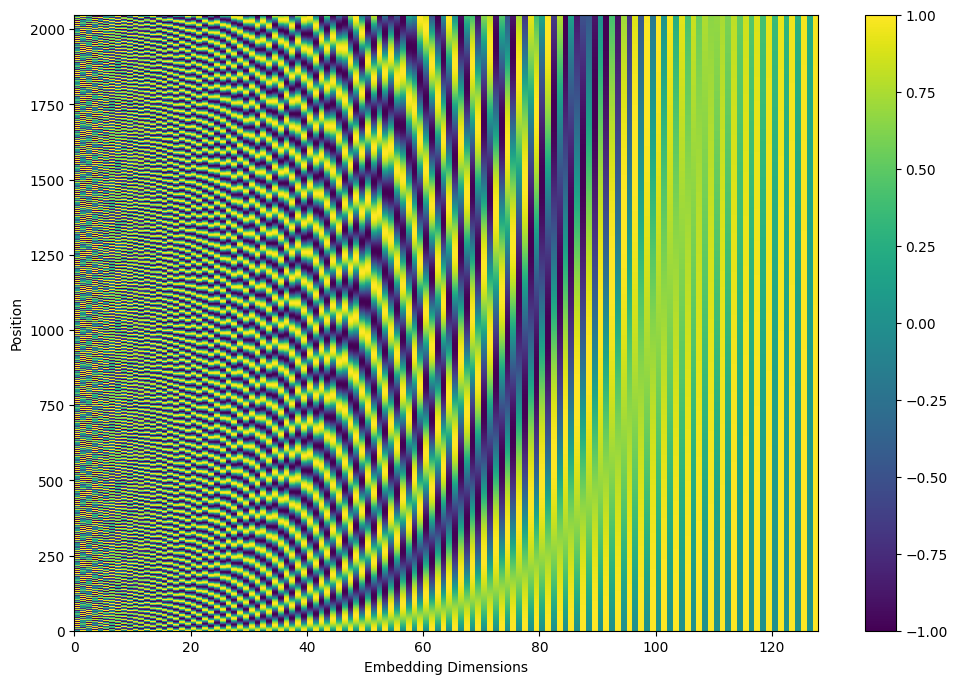

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.pcolormesh(pos_encoding, cmap='viridis')
plt.xlabel('Embedding Dimensions')
plt.xlim((0, emb_dim))
plt.ylabel('Position')
plt.colorbar()
plt.show()

Ahora, si pasamos nuestra frase simple por el tokenizador, deberíamos obtener una matriz con la forma: $(longitud, d_{model})$:

In [ ]:
text = "hola mundo!"
tokens = spanish_news_tokenizer(text, max_length=max_len, truncation=True, padding='max_length')
x = torch.tensor(tokens['input_ids']).unsqueeze(0)
mask = torch.tensor(tokens['input_ids']).unsqueeze(0)
embedding = tpe(x)
embedding.shape

torch.Size([1, 2048, 128])

### Multi-Head Attention

![](https://github.com/Ohtar10/icesi-nlp/blob/main/assets/mh-attention.png?raw=1)

Ahora procedemos a definir al núcleo del modelo. Recodemos que la atención se define por:

$$
\text{Attention}(Q, K, V) = \text{softmax}(\frac{QK^T}{\sqrt{d_K}})V
$$

Que es la definición de "Scaled Dot-Product Attention". Y Multi-Head Attention es la concatenación de varias cabezas ejecutando el mismo scaled dot-product sobre partes del input. Entonces tenemos:

In [ ]:
import math


class MultiHeadAttention(nn.Module):

    def __init__(self, embed_size: int, num_heads: int = 8):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.num_heads = num_heads
        assert embed_size & num_heads == 0, 'El tamaño del embedding debería ser divisible por el numero de cabezas'
        self.projection_dim = embed_size // num_heads
        self.query = nn.Linear(emb_dim, emb_dim)
        self.key = nn.Linear(emb_dim, emb_dim)
        self.value = nn.Linear(emb_dim, emb_dim)
        self.comibe_heads = nn.Linear(emb_dim, emb_dim)


    @staticmethod
    def _scaled_dot_product(q, k, v, mask=None):
        """scaled dot product.

        Esta función define el bloque mencionado.
        Aquí se hace la multiplicación de matrices
        entre los Q, K y V para luego calcular el
        score de atención.

        Nótese además que aquí aplicamos una máscara
        de atención. Esto se debe a que como estamos
        rellenando las cadenas cortas con un token que
        en si mismo no trae ningún significado, no queremos
        que la red desperdicie recursos operando sobre este
        token, entonces usamos la máscara para poner los valores
        de atención en numeros muy pequeños para que al
        calcular el score, estos no sobresalgan sobre los demás.
        """
        # d_k para el escalamiento
        d_k = q.size()[-1]

        # multiplicacion Q \cdot K^T
        attn_logits = torch.matmul(q, k.transpose(-2, -1))
        # escalamiento
        attn_logits = attn_logits / math.sqrt(d_k)

        # Se aplica la máscara
        if mask is not None:
            attn_logits = attn_logits.masked_fill(mask.reshape(mask.shape[0], 1, 1, -1) == 0, -9e-15)

        # Se calcula el score de atención.
        attention = torch.softmax(attn_logits, dim=-1)
        # Se obtienen los valores tras el score de atención.
        values = torch.matmul(attention, v)
        return values, attention


    def _separate_heads(self, x, batch_size):
        # Llega: (batch, seq_len, emb_dim)
        x =  x.reshape(batch_size, -1, self.num_heads, self.projection_dim)  # (batch, seq_len, num_heads, emb_dim / num_heads)
        return x.permute(0, 2, 1, 3)  # (batch, num_heads, seq_len, emb_dim / num_heads)


    def forward(self, x, mask=None, return_attention=False):
        """forward

        Este es todo el forward pass del multi-head attention.
        Aquí se coordina el resto de las operaciones, como
        la concatenación de las múltiples cabezas como
        el paso por la capa densa previo a entregar el
        resultado.
        """
        # x: (batch, seq_len, emb_dim)
        batch_size, seq_len, emb_dim = x.size()
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        q = self._separate_heads(q, batch_size)
        k = self._separate_heads(k, batch_size)
        v = self._separate_heads(v, batch_size)

        weights, attention = self._scaled_dot_product(q, k, v, mask)
        weights = weights.permute(0, 2, 1, 3) # (batch, seq_len, num_heads, emb_dim / num_heads)
        weights = weights.reshape(batch_size, seq_len, emb_dim)
        output = self.comibe_heads(weights)

        if return_attention:
            return output, attention
        else:
            return output


Podemos hacer una prueba rápida de que las operaciones funcionan a nivel de matrices.

In [ ]:
mha = MultiHeadAttention(emb_dim)
mha(embedding, mask).shape

torch.Size([1, 2048, 128])

### Definición del bloque transformers

![](https://github.com/Ohtar10/icesi-nlp/blob/main/assets/transformers-achitecture.png?raw=1)

Finalmente, definimos el bloque de transformers. Recordemos que como esta es una tarea de clasificación, solamente necesitamos el encoder, por lo que esto es silamente la primera parte del diseño de arquitecura de red.

En esta capa, simplemente ponemos una capa densa adicional junto con las normalizaciones a nivel de capa.

In [ ]:
class TransformerBlock(nn.Module):

    def __init__(self, emb_dim: int, num_heads: int = 8):
        super(TransformerBlock, self).__init__()
        self.mhatt = MultiHeadAttention(emb_dim, num_heads)
        self.mhatt_dropput = nn.Dropout(0.2)
        self.ffn = nn.Sequential(
            nn.Linear(emb_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, emb_dim)
        )
        self.layer_norm1 = nn.LayerNorm(emb_dim)
        self.layer_norm2 = nn.LayerNorm(emb_dim)


    def forward(self, x, mask=None):
        attn_output = self.mhatt(x, mask)
        attn_output = self.mhatt_dropput(attn_output)
        attn_output = self.layer_norm1(attn_output)
        ffn_out = self.ffn(attn_output)
        return self.layer_norm2(ffn_out)


Nuevamente, probamos rapidamente para asegurarnos que las capas operan correctamente.

In [ ]:
tb = TransformerBlock(emb_dim)
tb(embedding, mask).shape

torch.Size([1, 2048, 128])

In [ ]:
num_heads = 8
vocab_size = spanish_news_tokenizer.vocab_size

token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)
transformer = TransformerBlock(emb_dim, num_heads)
ff = nn.Sequential(
    nn.Flatten(),
    nn.Linear(max_len * emb_dim, spanish_news_dataset.num_classes)
)

In [ ]:
it = iter(train_loader)
batch = next(it)
x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']

embeddings = token_embeddings(x)
assert embeddings.shape == (train_loader.batch_size, max_len, emb_dim)

attention = transformer(embeddings, mask)
attention.shape

torch.Size([4, 2048, 128])

In [ ]:
pred = ff(attention)
pred.shape

torch.Size([4, 12])

### Definición del clasificador

Finalmente, definimos el modelo en si. Este modelo constará de 3 capas:

- La tokenización, tal como la definimos anteriormente.
- El transformer, que acabamos de decinir.
- Una capa densa adicional que servirá como clasificador de aquello que nos entregue la capa del transformer.

Como este es un LightningModule, aquí definiremos el resto de funciones utilitarias para el entrenamiento de la tarea.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torchmetrics import Accuracy


class SpanishNewsClassifier(LightningModule):

    def __init__(self, max_len: int, vocab_size: int, num_classes: int, emb_dim: int, num_heads: int = 8):
        super(SpanishNewsClassifier, self).__init__()
        self.num_classes = num_classes

        self.token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)
        self.transformer = TransformerBlock(emb_dim, num_heads)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(max_len * emb_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
            nn.LogSoftmax(dim=1)
        )

        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_acc = Accuracy(task='multiclass', num_classes=num_classes)


    def forward(self, x, mask=None):
        embeddings = self.token_embeddings(x)
        attention = self.transformer(embeddings, mask)
        return self.classifier(attention)


    def training_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        loss = F.cross_entropy(y_hat, y)
        self.train_acc(y_hat, y)
        self.log('train-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train-acc', self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        loss = F.cross_entropy(y_hat, y)
        self.val_acc(y_hat, y)
        self.log('val-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val-acc', self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def test_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        self.test_acc(y_hat, y)
        self.log('test-acc', self.test_acc, prog_bar=True, on_step=False, on_epoch=True)


    def predict_step(self, batch):
        x, mask = batch['input_ids'], batch['attention_mask']
        return self(x, mask)


    def configure_optimizers(self):
        optimizer =  torch.optim.AdamW(self.parameters(), lr=2e-5, weight_decay=1e-5)
        return optimizer


model = SpanishNewsClassifier(max_len=spanish_news_dataset.seq_length, vocab_size=spanish_news_tokenizer.vocab_size, num_classes=spanish_news_dataset.num_classes, emb_dim=emb_dim)

tb_logger = TensorBoardLogger('tb_logs', name='TransformersClassifier')
callbacks=[EarlyStopping(monitor='train-loss', patience=3, mode='min')]
trainer = Trainer(max_epochs=10, devices=1, logger=tb_logger, callbacks=callbacks, precision="16-mixed")

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                 | Params
----------------------------------------------------------
0 | token_embeddings | TokenAndPosEmbedding | 6.4 M 
1 | transformer      | TransformerBlock     | 198 K 
2 | classifier       | Sequential           | 134 M 
3 | train_acc        | MulticlassAccuracy   | 0     
4 | val_acc          | MulticlassAccuracy   | 0     
5 | test_acc         | MulticlassAccuracy   | 0     
----------------------------------------------------------
140 M     Trainable params
0         Non-trainable params
140 M     Total params
563.804   Total estimated model params size (MB)


Epoch 9: 100%|██████████| 2040/2040 [02:36<00:00, 13.04it/s, v_num=3, val-loss=1.050, val-acc=0.780, train-loss=0.370, train-acc=0.880]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 2040/2040 [02:44<00:00, 12.40it/s, v_num=3, val-loss=1.050, val-acc=0.780, train-loss=0.370, train-acc=0.880]


Observemos el proceso de entrenamiento

In [ ]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir tb_logs/

Launching TensorBoard...

Y como es de esperarse, realizaremos la validación contra el conjunto de prueba.

In [ ]:
model.eval()
trainer.test(model, test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 255/255 [00:04<00:00, 53.51it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test-acc            0.7823529243469238
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test-acc': 0.7823529243469238}]

### Haciendo predicciones

Finalmente, vamos a hacer uso del modelo y ver que tan bueno es para la clasificación de noticias.

In [ ]:
predictions = trainer.predict(model, test_loader)
predictions = torch.cat(predictions, dim=0)
predictions = torch.argmax(predictions, dim=-1)
predictions = [spanish_news_dataset.id_2_class_map[pred] for pred in predictions.numpy()]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 255/255 [00:04<00:00, 56.23it/s]


In [ ]:
import pandas as pd

test_indices = test_dataset.indices
df = pd.DataFrame(data={
    "texto": dataset[test_indices]['text'],
    "tokens": [spanish_news_tokenizer(v)['input_ids'] for v in dataset[test_indices]['text']],
    "categoría": dataset[test_indices]['category'],
    'predicción': predictions
}, index=test_indices)

df['tokens_string'] = df.tokens.apply(lambda t: spanish_news_tokenizer.convert_ids_to_tokens(t))
df = df[["texto", "tokens", "tokens_string", "categoría", "predicción"]]
df.style.set_table_styles(
    [
        {'selector': 'td', 'props': [('word-wrap', 'break-word')]}
    ]
)
df.head(15)

Token indices sequence length is longer than the specified maximum sequence length for this model (2418 > 1024). Running this sequence through the model will result in indexing errors


,texto,tokens,tokens_string,categoría,predicción
5450,En Francia se adelantan al Martes de Carnaval ...,"[619, 4150, 309, 4723, 561, 330, 37214, 259, 2...","[En, ĠFrancia, Ġse, Ġadelan, tan, Ġal, ĠMartes...",alimentation,alimentation
1239,Las autoridades de Reino Unido han llevado a c...,"[1492, 5544, 259, 4734, 5283, 647, 4397, 264, ...","[Las, Ġautoridades, Ġde, ĠReino, ĠUnido, Ġhan,...",tech,tech
1572,Samsung ha sido el primero en apostar fuerte p...,"[21155, 386, 966, 289, 2543, 279, 7393, 3356, ...","[Samsung, Ġha, Ġsido, Ġel, Ġprimero, Ġen, Ġapo...",tech,tech
2633,Podcast: Play in new window | DownloadHoy conv...,"[10372, 26, 7876, 315, 8518, 10388, 1022, 2785...","[Podcast, :, ĠPlay, Ġin, Ġnew, Ġwindow, Ġ|, ĠD...",astronomy,astronomy
5255,Las versátiles zanahorias se han popularizado ...,"[1492, 14504, 26128, 309, 647, 31736, 394, 254...","[Las, ĠversÃ¡tiles, Ġzanahorias, Ġse, Ġhan, Ġp...",alimentation,alimentation
1567,Amazon acaba de hacer un nuevo e importante mo...,"[18865, 3747, 259, 817, 297, 948, 258, 1300, 3...","[Amazon, Ġacaba, Ġde, Ġhacer, Ġun, Ġnuevo, Ġe,...",tech,tech
2388,"RESUMEN:El síndrome de Kounis, angina alérgica...","[8724, 26, 544, 3907, 259, 42455, 12, 10436, 1...","[RESUMEN, :, El, ĠsÃŃndrome, Ġde, ĠKounis, ,, ...",medicine,medicine
5223,¿Te imaginas pagar el agua de una conserva de ...,"[1746, 6735, 46967, 5501, 289, 1699, 259, 347,...","[Â¿, Te, Ġimaginas, Ġpagar, Ġel, Ġagua, Ġde, Ġ...",alimentation,alimentation
6983,"Nexter, una empresa de KNDS, está mejorando el...","[34142, 12, 347, 1762, 259, 25917, 12, 618, 10...","[Nexter, ,, Ġuna, Ġempresa, Ġde, ĠKNDS, ,, Ġes...",military,military
10168,El Ibex 35 ha iniciado la sesión de este marte...,"[544, 27385, 3748, 386, 13642, 280, 5981, 259,...","[El, ĠIbex, Ġ35, Ġha, Ġiniciado, Ġla, ĠsesiÃ³n...",economy,economy


In [ ]:
errors = df[df['categoría'] != df['predicción']]
errors.head(15)

,texto,tokens,tokens_string,categoría,predicción
9120,El seguro de tu furgoneta camper es totalmente...,"[544, 2946, 259, 972, 28463, 46389, 291, 4077,...","[El, Ġseguro, Ġde, Ġtu, Ġfurgoneta, Ġcamper, Ġ...",motor,astronomy
9142,¡Míralo! ¡Desde este ángulo trasero parece un ...,"[2050, 45, 2919, 2684, 1, 3241, 3526, 486, 108...","[Â¡, M, ÃŃr, alo, !, ĠÂ¡, Desde, Ġeste, ĠÃ¡ngu...",motor,tech
4900,La modelo Zoe Sozo Bethel ganó el año pasado M...,"[606, 1388, 40036, 2367, 862, 4041, 1194, 366,...","[La, Ġmodelo, ĠZoe, ĠSo, zo, ĠBe, th, el, Ġgan...",fashion,play
9642,El Ministerio de Economía ha puesto este viern...,"[544, 2995, 259, 8891, 386, 2294, 486, 4288, 2...","[El, ĠMinisterio, Ġde, ĠEconomÃŃa, Ġha, Ġpuest...",economy,politics
1209,El lanzamiento de los nuevos Xiaomi 14 y de es...,"[544, 3695, 259, 313, 1724, 6980, 1854, 290, 2...","[El, Ġlanzamiento, Ġde, Ġlos, Ġnuevos, ĠXiaomi...",tech,military
1285,"Ya es oficial, los Google Pixel 8 y Google Pix...","[5407, 291, 3389, 12, 313, 3999, 9626, 1034, 2...","[Ya, Ġes, Ġoficial, ,, Ġlos, ĠGoogle, ĠPixel, ...",tech,play
10162,"La Plataforma 6-F, organizada en redes sociale...","[606, 18475, 813, 13, 38, 12, 16019, 279, 2948...","[La, ĠPlataforma, Ġ6, -, F, ,, Ġorganizada, Ġe...",economy,politics
2794,La Academia de Ciencias de California inauguró...,"[606, 10290, 259, 4886, 259, 11579, 34834, 321...","[La, ĠAcademia, Ġde, ĠCiencias, Ġde, ĠCaliforn...",astronomy,religion
6942,Gracias a la integración del Expodrónica Pavil...,"[8866, 264, 280, 4866, 323, 25212, 594, 2729, ...","[Gracias, Ġa, Ġla, ĠintegraciÃ³n, Ġdel, ĠExpo,...",military,medicine
1392,Llevamos años esperando avances similares cada...,"[30130, 640, 11274, 6657, 5431, 889, 870, 288,...","[Llevamos, ĠaÃ±os, Ġesperando, Ġavances, Ġsimi...",tech,play


# Nuevo Datset:

Se plantea explorar el dataset stanford-oval/ccnews, disponible en Huggingface.

Este conjunto de datos se creó mediante la extracción de información del repositorio institucional de investigación de la Universidad del Rosario (Colombia).

Contiene resúmenes académicos en español etiquetados por la facultad de origen, lo que permite la capacitación y evaluación supervisadas para la clasificación de facultades y tareas de modelado de texto específicas del dominio.

Resumen del conjunto de datos

El objetivo de este conjunto de datos es predecir la facultad o unidad académica de un artículo basándose únicamente en su resumen.

Recopilamos todos los artículos académicos disponibles del repositorio institucional de la universidad, centrándonos en las publicaciones de acceso abierto.

De estos documentos, extrajimos:

- El resumen (en español)
- Autores
- Año de publicación
- Facultad/Departamento

Tras la limpieza y normalización, cada entrada se etiquetó según una de las seis facultades principales:

Facultad - Número de muestras
- Administración de Empresas 3.876
- Medicina 3.829
- Ciencias Políticas 2.691
- Derecho 1.660
- Economía 1.076
- Ingeniería 115

Total: 13.247 resúmenes (tras el filtrado y la normalización).

In [1]:

from datasets import load_dataset
from tqdm import tqdm
import json
dataset = load_dataset("Flaglab/academic-knowledge-abstracts-es")
# Flaglab/academic-knowledge-abstracts-es

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/7.63M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/966k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/962k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10021 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1253 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1253 [00:00<?, ? examples/s]

Se unen las columnas titulo y resumen para utilizar toda la informacion disponible para clasificacion.

In [2]:
def merge_text(example):
    titulo = example["titulo"] if example["titulo"] else ""
    resumen = example["resumen"] if example["resumen"] else ""

    example["text"] = f"{titulo}. {resumen}"
    return example

dataset = dataset.map(merge_text)

Map:   0%|          | 0/10021 [00:00<?, ? examples/s]

Map:   0%|          | 0/1253 [00:00<?, ? examples/s]

Map:   0%|          | 0/1253 [00:00<?, ? examples/s]

In [5]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['titulo', 'resumen', 'facultad', 'text'],
        num_rows: 10021
    })
    validation: Dataset({
        features: ['titulo', 'resumen', 'facultad', 'text'],
        num_rows: 1253
    })
    test: Dataset({
        features: ['titulo', 'resumen', 'facultad', 'text'],
        num_rows: 1253
    })
})


Analisamos tamaño de los articulos.

In [6]:
text_lengths = [len(row['resumen']) for row in dataset['train']]
print(f"Texto más corto: {min(text_lengths)}")
print(f"Texto más largo: {max(text_lengths)}")
print(f"Longitud promedio: {sum(text_lengths) / len(text_lengths)}")

Texto más corto: 114
Texto más largo: 20788
Longitud promedio: 1196.340584771979


Shape: (10021, 4)

Columnas: ['titulo', 'resumen', 'facultad', 'text']

Valores nulos:
 titulo      0
resumen     0
facultad    0
text        0
dtype: int64

Distribución de clases:
facultad
Administracion de empresas    3043
medicina                      2969
Gobierno                      2106
Derecho                       1304
economía                       599
Name: count, dtype: int64


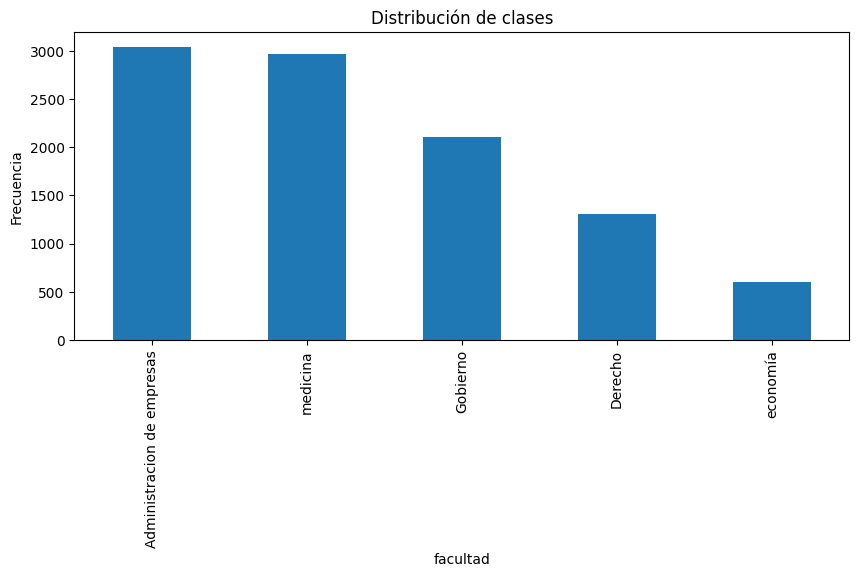


Estadísticas longitud caracteres:
count    10021.000000
mean      1301.424608
std        797.983055
min        154.000000
25%        770.000000
50%       1174.000000
75%       1714.000000
max      20843.000000
Name: char_length, dtype: float64

Estadísticas longitud palabras:
count    10021.000000
mean       199.021056
std        122.737017
min         22.000000
25%        119.000000
50%        180.000000
75%        260.000000
max       3329.000000
Name: word_length, dtype: float64


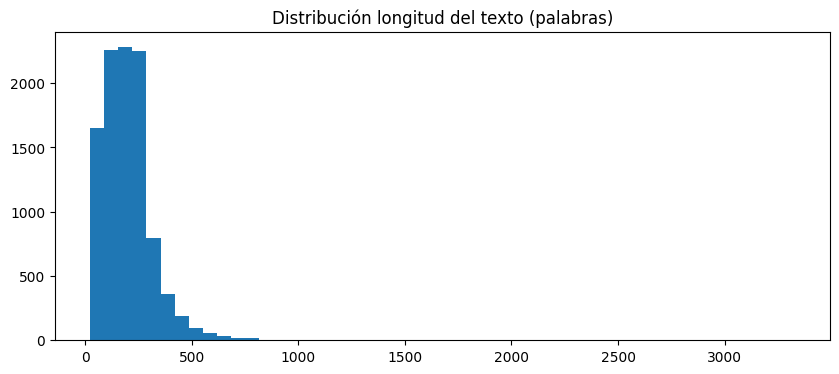

Token indices sequence length is longer than the specified maximum sequence length for this model (2396 > 1024). Running this sequence through the model will result in indexing errors



Longitud de tokens:
count    10021.000000
mean       236.000798
std        147.820709
min         27.000000
25%        138.000000
50%        210.000000
75%        309.000000
max       3834.000000
Name: token_length, dtype: float64


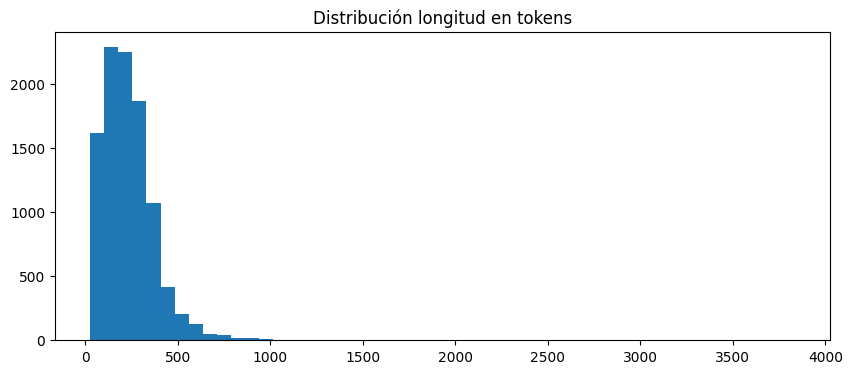


Top 20 palabras más frecuentes:
[('de', 171908), ('la', 93758), ('en', 68661), ('y', 64658), ('el', 60118), ('los', 37634), ('que', 35181), ('a', 32987), ('se', 32845), ('del', 28530), ('las', 27436), ('con', 22799), ('para', 20925), ('un', 19894), ('una', 17979), ('por', 15000), ('como', 13058), ('es', 10338), ('al', 9013), ('su', 8330)]

Longitud promedio por clase:
facultad
Gobierno                      148.180437
economía                      166.081803
Derecho                       169.483129
Administracion de empresas    198.852448
medicina                      254.875379
Name: word_length, dtype: float64


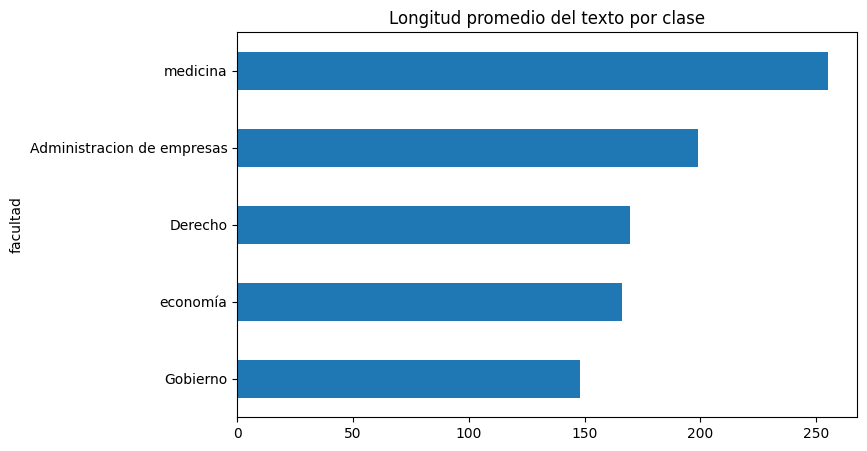


Ejemplos del dataset:

Clase: Administracion de empresas
Texto: MurMur.  Idea de negocio MurMur es una empresa colombiana de ropa femenina creada en el 2020.La marca tiene un enfoque ambiental y ofrece al cliente además de comprar ropa en tendencia, la oportunidad de poder reciclar o donar aquellas prendas que ya no utilice. El producto principal son prendas femeninas entre las que se destacan blusas, chaquetas, blazers, pantalones, crop tops, sudaderas, sacos

Clase: Gobierno
Texto: Política exterior de Estados Unidos dirigida al fortalecimiento de la democracia en Venezuela.  El gobierno de George Bush requirió del establecimiento de un programa de asistencia democrática de la Agencia Federal para el desarrollo USAID en Venezuela, con el fin de contrarestar la aparición del fenómeno chavista. 

Clase: medicina
Texto: La psicosis : un acercamiento desde la teoría de Wilfred Bion.  Este texto pretende hacer un acercamiento a la definición de la psicosis a partir de la revisión de la o

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re

# ---------------------------------
# 1. Convertir a DataFrame (solo train para EDA)
# ---------------------------------

df = dataset["train"].to_pandas()

print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nValores nulos:\n", df.isnull().sum())

# ---------------------------------
# 2. Distribución de clases
# ---------------------------------

print("\nDistribución de clases:")
class_dist = df["facultad"].value_counts()

print(class_dist)

plt.figure(figsize=(10,4))
class_dist.plot(kind="bar")
plt.title("Distribución de clases")
plt.ylabel("Frecuencia")
plt.show()

# ---------------------------------
# 3. Longitud de texto
# ---------------------------------

df["char_length"] = df["text"].apply(len)
df["word_length"] = df["text"].apply(lambda x: len(x.split()))

print("\nEstadísticas longitud caracteres:")
print(df["char_length"].describe())

print("\nEstadísticas longitud palabras:")
print(df["word_length"].describe())

plt.figure(figsize=(10,4))
plt.hist(df["word_length"], bins=50)
plt.title("Distribución longitud del texto (palabras)")
plt.show()

# ---------------------------------
# 4. Longitud de tokens (según tokenizer)
# ---------------------------------

def token_length(text):
    return len(spanish_news_tokenizer.encode(text, truncation=False))

df["token_length"] = df["text"].apply(token_length)

print("\nLongitud de tokens:")
print(df["token_length"].describe())

plt.figure(figsize=(10,4))
plt.hist(df["token_length"], bins=50)
plt.title("Distribución longitud en tokens")
plt.show()

# ---------------------------------
# 5. Palabras más frecuentes
# ---------------------------------

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return text

all_words = []

for text in df["text"]:
    words = clean_text(text).split()
    all_words.extend(words)

word_freq = Counter(all_words)

print("\nTop 20 palabras más frecuentes:")
print(word_freq.most_common(20))

# ---------------------------------
# 6. Longitud promedio por clase
# ---------------------------------

class_stats = df.groupby("facultad")["word_length"].mean().sort_values()

print("\nLongitud promedio por clase:")
print(class_stats)

class_stats.plot(kind="barh", figsize=(8,5))
plt.title("Longitud promedio del texto por clase")
plt.show()

# ---------------------------------
# 7. Ejemplos del dataset
# ---------------------------------

print("\nEjemplos del dataset:")

for i in range(3):
    print("\nClase:", df.iloc[i]["facultad"])
    print("Texto:", df.iloc[i]["text"][:400])

**Tokenizer**

In [12]:
from tqdm.auto import tqdm
from transformers import AutoTokenizer
from transformers.models.gpt2.tokenization_gpt2 import bytes_to_unicode


length = len(dataset['train']) # Changed from 10000 to actual dataset length
# iter_dataset = iter(dataset['train']) # Removed: no longer needed as we iterate by index
tokenizer = AutoTokenizer.from_pretrained("gpt2")

byte_to_unicode_map = bytes_to_unicode()
unicode_to_byte_map = dict((v, k) for k, v in byte_to_unicode_map.items())
base_vocab = list(unicode_to_byte_map.keys())

def batch_iterator(): # Removed batch_size parameter as it now yields one item at a time
    # Yield individual text samples for tokenizer training
    for i in tqdm(range(length)): # Iterate through all items in the dataset
        yield dataset['train'][i]['text'] # Access text directly by index

spanish_news_tokenizer = tokenizer.train_new_from_iterator(batch_iterator(), vocab_size=50000, initial_alphabet=base_vocab, length=length)

  0%|          | 0/10021 [00:00<?, ?it/s]

In [13]:
tokens = sorted(spanish_news_tokenizer.vocab.items(), key=lambda x: x[1], reverse=False)
print(f"Vocabulario: {spanish_news_tokenizer.vocab_size} tokens")
print("Primeros 15 tokens:")
print([f"{spanish_news_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[:15]])
print("15 tokens de en medio:")
print([f"{spanish_news_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[1000:1015]])
print("Últimos 15 tokens:")
print([f"{spanish_news_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[-15:]])

Vocabulario: 50000 tokens
Primeros 15 tokens:
['<|endoftext|>', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.']
15 tokens de en medio:
[' tom', ' ve', ' aplic', ' gra', 'rendi', ' tu', ' herramien', ' mejora', ' deci', ' relacion', ' enfo', ' diagnós', ' cli', ' personas', ' vida']
Últimos 15 tokens:
[' bolívar', ' bisa', ' bélicas', ' bridas', ' bélica', ' bupivacaina', ' bicamerales', ' breves', ' cae', ' caj', ' camente', ' caba', ' cables', ' cauca', ' caótica']


## Revisamos otro Tokenizador:

**bert-base-uncased** tokenizer

Se espera que el cambio de tokenizador, optimice la velocidad de entrenamiento, al tener menor cantidad de tokens, se vuelve mas eficiente el uso de la memoria.

Cambios esperados:

- menor memoria
- tokenización más rápida
- menos parámetros en embeddings

In [3]:
from transformers import AutoTokenizer
from tqdm import tqdm

length = len(dataset["train"])

# Tokenizador base optimizado para clasificación
tokenizer2 = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")

def batch_iterator():
    for i in tqdm(range(length)):
        yield dataset["train"][i]["text"]

# Entrenar nuevo tokenizer sobre tu dataset
spanish_news_tokenizer2 = tokenizer2.train_new_from_iterator(
    batch_iterator(),
    vocab_size=32000,
    length=length
)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

100%|██████████| 10021/10021 [00:04<00:00, 2290.85it/s]


In [51]:
tokens2 = sorted(spanish_news_tokenizer2.vocab.items(), key=lambda x: x[1], reverse=False)
print(f"Vocabulario: {spanish_news_tokenizer2.vocab_size} tokens")
print("Primeros 15 tokens:")
print([f"{spanish_news_tokenizer2.convert_tokens_to_string([t])}" for t, _ in tokens[:15]])
print("15 tokens de en medio:")
print([f"{spanish_news_tokenizer2.convert_tokens_to_string([t])}" for t, _ in tokens[1000:1015]])
print("Últimos 15 tokens:")
print([f"{spanish_news_tokenizer2.convert_tokens_to_string([t])}" for t, _ in tokens[-15:]])

Vocabulario: 32000 tokens
Primeros 15 tokens:
['<|endoftext|>', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.']
15 tokens de en medio:
['Ġtom', 'Ġve', 'Ġaplic', 'Ġgra', 'rendi', 'Ġtu', 'Ġherramien', 'Ġmejora', 'Ġdeci', 'Ġrelacion', 'Ġenfo', 'ĠdiagnÃ³s', 'Ġcli', 'Ġpersonas', 'Ġvida']
Últimos 15 tokens:
['ĠbolÃŃvar', 'Ġbisa', 'ĠbÃ©licas', 'Ġbridas', 'ĠbÃ©lica', 'Ġbupivacaina', 'Ġbicamerales', 'Ġbreves', 'Ġcae', 'Ġcaj', 'Ġcamente', 'Ġcaba', 'Ġcables', 'Ġcauca', 'ĠcaÃ³tica']


Funcion para dataset de Pytorch

In [4]:
import torch
import numpy as np
from typing import Tuple, Dict
from torch.utils.data import Dataset

class SpanishNewsDataset(Dataset):

    def __init__(self, tokenizer, dataset, seq_length: int = 512):
        self.tokenizer = tokenizer
        self.tokenizer.pad_token = '[PAD]'
        self.dataset = dataset
        self.seq_length = seq_length
        # Definimos estos dos mapas para facilitarnos la tarea
        # de traducir de nombres de categoría a ids de categoría.
        self.id_2_class_map = dict(enumerate(np.unique(dataset[:]['facultad'])))
        self.class_2_id_map = {v: k for k, v in self.id_2_class_map.items()}
        self.num_classes = len(self.id_2_class_map)

    def __getitem__(self, index) -> Dict[str, torch.Tensor]:
        text, y = self.dataset[index]['text'], self.dataset[index]['facultad']
        y = self.class_2_id_map[y]
        data = {k: torch.tensor(v) for k, v in self.tokenizer(text, max_length=self.seq_length, truncation=True, padding='max_length').items()}
        data['y'] = torch.tensor(y)
        return data


    def __len__(self):
        return len(self.dataset)

Division del dataset en train y test

In [25]:
from torch.utils.data import random_split
from torch.utils.data import DataLoader

batch_size = 4 if not IN_COLAB else 16
max_len = 2048

train_dataset = SpanishNewsDataset(spanish_news_tokenizer, dataset["train"], seq_length=max_len)
val_dataset = SpanishNewsDataset(spanish_news_tokenizer, dataset["validation"], seq_length=max_len)
test_dataset = SpanishNewsDataset(spanish_news_tokenizer, dataset["test"], seq_length=max_len)

assert len(train_dataset) == len(dataset["train"])
assert len(val_dataset) == len(dataset["validation"])
assert len(test_dataset) == len(dataset["test"])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

Definicion del Positional Embedings

In [5]:
import numpy as np
import torch.nn as nn
from enum import Enum
from typing import Optional


class PosEncodingType(Enum):
    SINUSOID = 1
    LEARNABLE = 2


class SinusoidPE(nn.Module):

    def __init__(self, max_len: int, d_model: int):
        super(SinusoidPE, self).__init__()

        # Definimos un vector columna con las posiciones de la secuencia de entrada (pos)
        pos = torch.arange(max_len).unsqueeze(1)
        # Definimos un vector de fila con las dimensiones del embedding (i)
        i = torch.arange(d_model).unsqueeze(0)

        # Calculamos el denominador segun la formula
        div_term = 1 / torch.pow(10000, (2 * (i // 2)) / torch.tensor(d_model, dtype=torch.float32))
        # Aplicamos el denominador a las posiciones
        angle_rads = pos * div_term

        # Inicializamos la matriz de positional encodings
        pos_encoding = torch.zeros(max_len, d_model)
        # Calculamos los embeddings para los numeros pares con seno: PE(pos, 2i)
        pos_encoding[:, 0::2] = torch.sin(angle_rads[:, 0::2])
        # Calculamos los embdeddings para los numeros inpares con coseno: PE(pos, 2i+1)
        pos_encoding[:, 1::2] = torch.cos(angle_rads[:, 1::2])

        # Registramos la variable como atributo de clase
        self.register_buffer("pos_encoding", pos_encoding.unsqueeze(0), persistent=False)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pos_encoding[:, :x.size(1), :]


class LearnablePE(nn.Module):

    def __init__(self, vocab_size: int, d_model: int, max_len: int = float('-inf')):
        super(LearnablePE, self).__init__()
        self.max_len = max_len
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        positions = torch.arange(0, max(x.size(-1), self.max_len))
        pos_emb = self.embedding(positions)
        return x + pos_emb



class TokenAndPosEmbedding(nn.Module):

    def __init__(self, max_len: int, embed_dim: int, vocab_size: int, pos_encoding_type: PosEncodingType = PosEncodingType.SINUSOID):
        super(TokenAndPosEmbedding, self).__init__()
        self.token_emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
        if pos_encoding_type == PosEncodingType.SINUSOID:
            self.pos_emb = SinusoidPE(max_len, embed_dim)
        else:
            self.pos_emb = LearnablePE(vocab_size, embed_dim)


    def forward(self, x):
        token_emb = self.token_emb(x)
        return self.pos_emb(token_emb)

modulo que va a convertir los tokens en embeddings con positional embeddings.

In [27]:
emb_dim = 128 if not IN_COLAB else 256
tpe = TokenAndPosEmbedding(max_len, emb_dim, spanish_news_tokenizer.vocab_size)
pos_encoding = tpe.pos_emb.pos_encoding.squeeze(0).numpy()

Multi Head Attention

In [6]:
import math


class MultiHeadAttention(nn.Module):

    def __init__(self, embed_size: int, num_heads: int = 8):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.num_heads = num_heads
        assert embed_size & num_heads == 0, 'El tamaño del embedding debería ser divisible por el numero de cabezas'
        self.projection_dim = embed_size // num_heads
        self.query = nn.Linear(emb_dim, emb_dim)
        self.key = nn.Linear(emb_dim, emb_dim)
        self.value = nn.Linear(emb_dim, emb_dim)
        self.comibe_heads = nn.Linear(emb_dim, emb_dim)


    @staticmethod
    def _scaled_dot_product(q, k, v, mask=None):
        """scaled dot product.

        Esta función define el bloque mencionado.
        Aquí se hace la multiplicación de matrices
        entre los Q, K y V para luego calcular el
        score de atención.

        Nótese además que aquí aplicamos una máscara
        de atención. Esto se debe a que como estamos
        rellenando las cadenas cortas con un token que
        en si mismo no trae ningún significado, no queremos
        que la red desperdicie recursos operando sobre este
        token, entonces usamos la máscara para poner los valores
        de atención en numeros muy pequeños para que al
        calcular el score, estos no sobresalgan sobre los demás.
        """
        # d_k para el escalamiento
        d_k = q.size()[-1]

        # multiplicacion Q \cdot K^T
        attn_logits = torch.matmul(q, k.transpose(-2, -1))
        # escalamiento
        attn_logits = attn_logits / math.sqrt(d_k)

        # Se aplica la máscara
        if mask is not None:
            attn_logits = attn_logits.masked_fill(mask.reshape(mask.shape[0], 1, 1, -1) == 0, -9e-15)

        # Se calcula el score de atención.
        attention = torch.softmax(attn_logits, dim=-1)
        # Se obtienen los valores tras el score de atención.
        values = torch.matmul(attention, v)
        return values, attention


    def _separate_heads(self, x, batch_size):
        # Llega: (batch, seq_len, emb_dim)
        x =  x.reshape(batch_size, -1, self.num_heads, self.projection_dim)  # (batch, seq_len, num_heads, emb_dim / num_heads)
        return x.permute(0, 2, 1, 3)  # (batch, num_heads, seq_len, emb_dim / num_heads)


    def forward(self, x, mask=None, return_attention=False):
        """forward

        Este es todo el forward pass del multi-head attention.
        Aquí se coordina el resto de las operaciones, como
        la concatenación de las múltiples cabezas como
        el paso por la capa densa previo a entregar el
        resultado.
        """
        # x: (batch, seq_len, emb_dim)
        batch_size, seq_len, emb_dim = x.size()
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        q = self._separate_heads(q, batch_size)
        k = self._separate_heads(k, batch_size)
        v = self._separate_heads(v, batch_size)

        weights, attention = self._scaled_dot_product(q, k, v, mask)
        weights = weights.permute(0, 2, 1, 3) # (batch, seq_len, num_heads, emb_dim / num_heads)
        weights = weights.reshape(batch_size, seq_len, emb_dim)
        output = self.comibe_heads(weights)

        if return_attention:
            return output, attention
        else:
            return output

Bloque Transformer

In [7]:
class TransformerBlock(nn.Module):

    def __init__(self, emb_dim: int, num_heads: int = 8):
        super(TransformerBlock, self).__init__()
        self.mhatt = MultiHeadAttention(emb_dim, num_heads)
        self.mhatt_dropput = nn.Dropout(0.2)
        self.ffn = nn.Sequential(
            nn.Linear(emb_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, emb_dim)
        )
        self.layer_norm1 = nn.LayerNorm(emb_dim)
        self.layer_norm2 = nn.LayerNorm(emb_dim)


    def forward(self, x, mask=None):
        attn_output = self.mhatt(x, mask)
        attn_output = self.mhatt_dropput(attn_output)
        attn_output = self.layer_norm1(attn_output)
        ffn_out = self.ffn(attn_output)
        return self.layer_norm2(ffn_out)


In [31]:
num_heads = 8
vocab_size = spanish_news_tokenizer.vocab_size

token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)
transformer = TransformerBlock(emb_dim, num_heads)
ff = nn.Sequential(
    nn.Flatten(),
    nn.Linear(max_len * emb_dim, train_dataset.num_classes)
)

In [32]:
it = iter(train_loader)
batch = next(it)
x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']

embeddings = token_embeddings(x)
assert embeddings.shape == (train_loader.batch_size, max_len, emb_dim)

attention = transformer(embeddings, mask)
attention.shape

torch.Size([16, 2048, 256])

In [33]:
pred = ff(attention)
pred.shape

torch.Size([16, 5])

Definicion del clasificador

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torchmetrics import Accuracy

class SpanishNewsClassifier(LightningModule):

    def __init__(self, max_len, vocab_size, num_classes, emb_dim=256, num_heads=4):
        super().__init__()

        self.num_classes = num_classes

        # Embedding + positional encoding
        self.token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)

        # Transformer block
        self.transformer = TransformerBlock(emb_dim, num_heads)

        # Pooling (reemplaza Flatten)
        self.pool = nn.AdaptiveAvgPool1d(1)

        # Clasificador
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

        # Métricas
        self.train_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc = Accuracy(task="multiclass", num_classes=num_classes)


    def forward(self, x, mask=None):

        x = self.token_embeddings(x)

        x = self.transformer(x, mask)

        # pooling (batch, seq, emb) -> (batch, emb)
        x = x.transpose(1, 2)
        x = self.pool(x).squeeze(-1)

        logits = self.classifier(x)

        return logits


    def training_step(self, batch, batch_idx):

        x = batch["input_ids"]
        mask = batch["attention_mask"]
        y = batch["y"]

        logits = self(x, mask)

        loss = F.cross_entropy(logits, y)

        self.train_acc(logits, y)

        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", self.train_acc, prog_bar=True)

        return loss


    def validation_step(self, batch, batch_idx):

        x = batch["input_ids"]
        mask = batch["attention_mask"]
        y = batch["y"]

        logits = self(x, mask)

        loss = F.cross_entropy(logits, y)

        self.val_acc(logits, y)

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", self.val_acc, prog_bar=True)


    def test_step(self, batch, batch_idx):

        x = batch["input_ids"]
        mask = batch["attention_mask"]
        y = batch["y"]

        logits = self(x, mask)

        self.test_acc(logits, y)

        self.log("test_acc", self.test_acc, prog_bar=True)


    def predict_step(self, batch, batch_idx):

        x = batch["input_ids"]
        mask = batch["attention_mask"]

        logits = self(x, mask)

        return torch.argmax(logits, dim=1)


    def configure_optimizers(self):

        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=2e-4,
            weight_decay=1e-5
        )

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            patience=2,
            factor=0.5
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }


# -----------------------------
# Instanciación del modelo
# -----------------------------

model = SpanishNewsClassifier(
    max_len=train_dataset.seq_length,
    vocab_size=spanish_news_tokenizer.vocab_size,
    num_classes=train_dataset.num_classes,
    emb_dim=256
)


# -----------------------------
# Logger
# -----------------------------

tb_logger = TensorBoardLogger(
    "tb_logs",
    name="TransformersClassifier"
)


# -----------------------------
# Callbacks
# -----------------------------

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        mode="min"
    )
]


# -----------------------------
# Trainer optimizado para Colab
# -----------------------------

trainer = Trainer(
    max_epochs=10,
    accelerator="auto",
    devices=1,
    precision="16-mixed",
    gradient_clip_val=1.0,
    log_every_n_steps=50,
    logger=tb_logger,
    callbacks=callbacks
)


# -----------------------------
# Entrenamiento
# -----------------------------

trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)


INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ token_embeddings │ TokenAndPosEmbedding │ 12.8 M │ train │     0 │
│ 1 │ transformer      │ TransformerBlock     │  527 K │ train │     0 │
│ 2 │ pool             │ AdaptiveAvgPool1d    │      0 │ train │     0 │
│ 3 │ classifier       │ Sequential           │ 67.1 K │ train │     0 │
│ 4 │ train_acc        │ MulticlassAccuracy   │      0 │ train │     0 │
│ 5 │ val_acc          │ MulticlassAccuracy   │      0 │ train │     0 │
│ 6 │ test_acc         │ MulticlassAccuracy   │      0 │ train │     0 │
└───┴──────────────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 13.4 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 13.4 M                                                                                               
Total estimated model params size (MB): 53                                                                         
Modules in train mode: 26                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Validacion con el set Test

In [37]:
model.eval()
trainer.test(model, test_loader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8108539581298828     │
└───────────────────────────┴───────────────────────────┘

[{'test_acc': 0.8108539581298828}]

Predicciones

In [41]:
predictions = trainer.predict(model, test_loader)
predictions = torch.cat(predictions, dim=0)
predictions = [test_dataset.id_2_class_map[pred] for pred in predictions.numpy()]

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

In [44]:
import pandas as pd

# Get original texts and categories directly from the HuggingFace dataset split
original_texts = dataset['test']['text']
original_categories = dataset['test']['facultad']

# Tokenize the original texts using the trained tokenizer
tokenized_ids = [spanish_news_tokenizer(text)['input_ids'] for text in original_texts]

df = pd.DataFrame(data={
    "texto": original_texts,
    "tokens": tokenized_ids,
    "categoría": original_categories,
    'predicción': predictions
})

df['tokens_string'] = df.tokens.apply(lambda t: spanish_news_tokenizer.convert_ids_to_tokens(t))
df = df[["texto", "tokens", "tokens_string", "categoría", "predicción"]]
df.style.set_table_styles(
    [
        {'selector': 'td', 'props': [('word-wrap', 'break-word')]}
    ]
)
df.head(15)

Token indices sequence length is longer than the specified maximum sequence length for this model (2236 > 1024). Running this sequence through the model will result in indexing errors


,texto,tokens,tokens_string,categoría,predicción
0,Estudio del manejo de residuos sólidos en el R...,"[3853, 319, 1210, 259, 4845, 7568, 277, 291, 4...","[Estudio, Ġdel, Ġmanejo, Ġde, Ġresiduos, ĠsÃ³l...",Gobierno,medicina
1,La influencia de la política de adquisición de...,"[1123, 1792, 259, 270, 918, 259, 5378, 259, 40...","[La, Ġinfluencia, Ġde, Ġla, ĠpolÃŃtica, Ġde, Ġ...",Gobierno,Gobierno
2,Thanatos empresarial : prolegómenos y causas. ...,"[30239, 1532, 1680, 335, 4309, 1767, 262, 286,...","[Thanatos, Ġempresarial, Ġ:, Ġpro, leg, Ã³men,...",Administracion de empresas,Administracion de empresas
3,Caracterización epidemiológica de pacientes co...,"[5009, 8045, 259, 533, 297, 9444, 4550, 286, 5...","[CaracterizaciÃ³n, ĠepidemiolÃ³gica, Ġde, Ġpac...",medicina,medicina
4,Aproximación teórica al fenómeno de la automed...,"[11300, 4195, 355, 2093, 259, 270, 15800, 739,...","[AproximaciÃ³n, ĠteÃ³rica, Ġal, ĠfenÃ³meno, Ġd...",medicina,Administracion de empresas
5,Factores promotores de los procesos de resilie...,"[3528, 17988, 259, 308, 1033, 259, 6056, 277, ...","[Factores, Ġpromotores, Ġde, Ġlos, Ġprocesos, ...",medicina,medicina
6,Usos y problemas de interpretación y aplicació...,"[53, 4106, 286, 1848, 259, 4359, 286, 1344, 25...","[U, sos, Ġy, Ġproblemas, Ġde, ĠinterpretaciÃ³n...",Derecho,Derecho
7,Jurisdicción constitucional. Las sentencias de...,"[39269, 3166, 14, 1092, 7484, 259, 12762, 377,...","[JurisdicciÃ³n, Ġconstitucional, ., ĠLas, Ġsen...",Derecho,Derecho
8,Las relaciones estado - ciudadano en Colombia ...,"[3664, 1455, 1345, 1166, 8383, 277, 507, 14213...","[Las, Ġrelaciones, Ġestado, Ġ-, Ġciudadano, Ġe...",Gobierno,Gobierno
9,Normative reference of standing long jump for ...,"[46, 655, 4887, 42571, 908, 272, 26110, 43934,...","[N, orma, tive, Ġreference, Ġof, Ġs, tanding, ...",medicina,medicina


In [45]:
errors = df[df['categoría'] != df['predicción']]
errors.head(15)

,texto,tokens,tokens_string,categoría,predicción
0,Estudio del manejo de residuos sólidos en el R...,"[3853, 319, 1210, 259, 4845, 7568, 277, 291, 4...","[Estudio, Ġdel, Ġmanejo, Ġde, Ġresiduos, ĠsÃ³l...",Gobierno,medicina
4,Aproximación teórica al fenómeno de la automed...,"[11300, 4195, 355, 2093, 259, 270, 15800, 739,...","[AproximaciÃ³n, ĠteÃ³rica, Ġal, ĠfenÃ³meno, Ġd...",medicina,Administracion de empresas
11,Sentimiento del mercado y minutas del banco ce...,"[51, 34963, 319, 795, 286, 1476, 5838, 319, 97...","[S, entimiento, Ġdel, Ġmercado, Ġy, Ġmin, utas...",economía,Administracion de empresas
14,Corporalidad y discapacidad intelectual: aport...,"[47805, 48475, 286, 2602, 5728, 26, 4303, 269,...","[Corpora, lidad, Ġy, Ġdiscapacidad, Ġintelectu...",medicina,Gobierno
16,"Estructuras organizacionales, esquemas salaria...","[17253, 83, 4997, 12, 7169, 18795, 286, 981, 5...","[Estructura, s, Ġorganizacionales, ,, Ġesquema...",economía,Administracion de empresas
17,Acompañamiento de la ciencia colombiana a las ...,"[33, 21797, 947, 259, 270, 4312, 1738, 269, 32...","[A, compaÃ±, amiento, Ġde, Ġla, Ġciencia, Ġcol...",economía,Derecho
26,Marca país como instrumento alternativo de acc...,"[45, 7188, 696, 377, 2503, 11855, 259, 2111, 1...","[M, arca, ĠpaÃŃs, Ġcomo, Ġinstrumento, Ġaltern...",Gobierno,Administracion de empresas
27,Validación de la escala de Rassi para la estra...,"[18209, 259, 270, 2125, 259, 26232, 402, 349, ...","[ValidaciÃ³n, Ġde, Ġla, Ġescala, Ġde, ĠRas, si...",medicina,Administracion de empresas
33,Capacidad de respuesta hospitalaria distrital ...,"[33266, 259, 2063, 3537, 9763, 277, 784, 1535,...","[Capacidad, Ġde, Ġrespuesta, Ġhospitalaria, Ġd...",medicina,Administracion de empresas
35,With a little help from my friends: Debt Reneg...,"[55, 4412, 269, 595, 29950, 20290, 80, 7820, 3...","[W, ith, Ġa, Ġli, ttle, Ġhel, p, Ġfrom, Ġmy, Ġ...",economía,Derecho


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


Accuracy: 0.8109

--- Métricas Macro ---
Precision: 0.7582
Recall: 0.7145
F1-score: 0.7242

--- Métricas Weighted ---
Precision: 0.8027
Recall: 0.8109
F1-score: 0.8024

--- Classification Report ---

                            precision    recall  f1-score   support

Administracion de empresas       0.80      0.88      0.84       381
                   Derecho       0.75      0.77      0.76       163
                  Gobierno       0.82      0.76      0.79       263
                  economía       0.56      0.25      0.35        75
                  medicina       0.87      0.90      0.88       371

                  accuracy                           0.81      1253
                 macro avg       0.76      0.71      0.72      1253
              weighted avg       0.80      0.81      0.80      1253



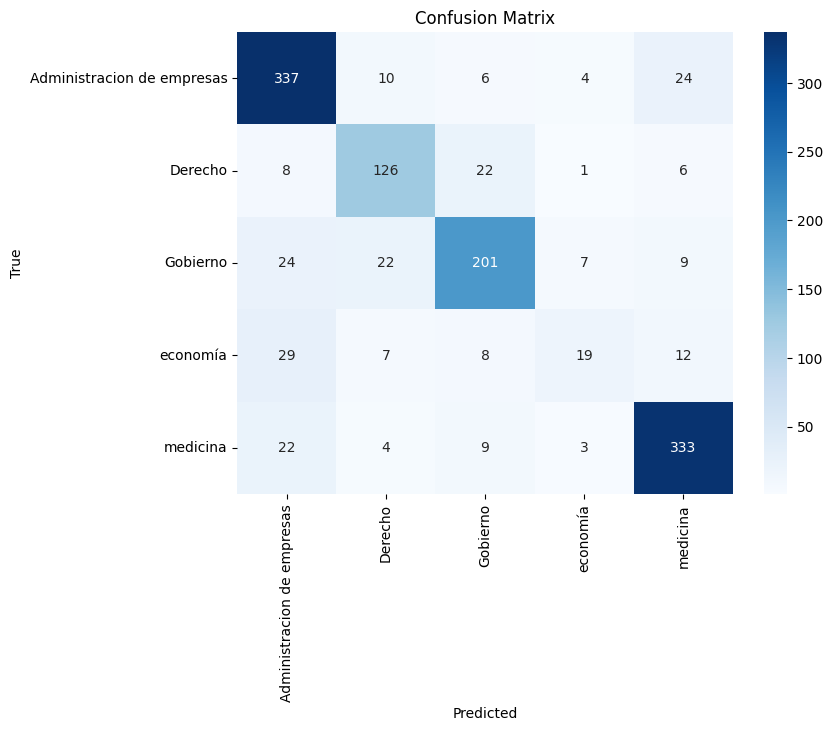


Distribución de predicciones:
Counter({np.str_('Administracion de empresas'): 420, np.str_('medicina'): 384, np.str_('Gobierno'): 246, np.str_('Derecho'): 169, np.str_('economía'): 34})

Accuracy por clase:

true
medicina                      0.897574
Administracion de empresas    0.884514
Derecho                       0.773006
Gobierno                      0.764259
economía                      0.253333
dtype: float64


In [48]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter


# --------------------------------------------------
# 1. Obtener predicciones del modelo
# --------------------------------------------------

predictions = trainer.predict(model, test_loader)

predictions = torch.cat(predictions, dim=0)

y_pred_ids = predictions.numpy()

y_pred = [test_dataset.id_2_class_map[p] for p in y_pred_ids]


# --------------------------------------------------
# 2. Obtener etiquetas reales
# --------------------------------------------------

# Correctly obtain true labels from the underlying dataset
y_true_categories = test_dataset.dataset['facultad']
y_true_ids = [test_dataset.class_2_id_map[cat] for cat in y_true_categories]
y_true = [test_dataset.id_2_class_map[y] for y in y_true_ids]


# --------------------------------------------------
# 3. Accuracy
# --------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

print("\nAccuracy:", round(accuracy, 4))


# --------------------------------------------------
# 4. Precision, Recall, F1
# --------------------------------------------------

precision_macro = precision_score(y_true, y_pred, average="macro")
recall_macro = recall_score(y_true, y_pred, average="macro")
f1_macro = f1_score(y_true, y_pred, average="macro")

precision_weighted = precision_score(y_true, y_pred, average="weighted")
recall_weighted = recall_score(y_true, y_pred, average="weighted")
f1_weighted = f1_score(y_true, y_pred, average="weighted")

print("\n--- Métricas Macro ---")
print("Precision:", round(precision_macro, 4))
print("Recall:", round(recall_macro, 4))
print("F1-score:", round(f1_macro, 4))

print("\n--- Métricas Weighted ---")
print("Precision:", round(precision_weighted, 4))
print("Recall:", round(recall_weighted, 4))
print("F1-score:", round(f1_weighted, 4))


# --------------------------------------------------
# 5. Classification report
# --------------------------------------------------

print("\n--- Classification Report ---\n")

print(classification_report(y_true, y_pred))


# --------------------------------------------------
# 6. Confusion Matrix
# --------------------------------------------------

labels = sorted(list(set(y_true)))

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()


# --------------------------------------------------
# 7. Distribución de predicciones
# --------------------------------------------------

print("\nDistribución de predicciones:")

print(Counter(y_pred))


# --------------------------------------------------
# 8. Accuracy por clase
# --------------------------------------------------

df_eval = pd.DataFrame({
    "true": y_true,
    "pred": y_pred
})

accuracy_per_class = df_eval.groupby("true").apply(
    lambda x: (x.true == x.pred).mean()
)

print("\nAccuracy por clase:\n")

print(accuracy_per_class.sort_values(ascending=False))

# Vamos a entrenar el modelo con el nuevo tokenizador y comparar el comportamiento

Division del dataset en train y test

In [10]:
from torch.utils.data import random_split
from torch.utils.data import DataLoader

batch_size = 4 if not IN_COLAB else 16
max_len = 2048

train_dataset2 = SpanishNewsDataset(spanish_news_tokenizer2, dataset["train"], seq_length=max_len)
val_dataset2 = SpanishNewsDataset(spanish_news_tokenizer2, dataset["validation"], seq_length=max_len)
test_dataset2 = SpanishNewsDataset(spanish_news_tokenizer2, dataset["test"], seq_length=max_len)

assert len(train_dataset2) == len(dataset["train"])
assert len(val_dataset2) == len(dataset["validation"])
assert len(test_dataset2) == len(dataset["test"])

train_loader2 = DataLoader(train_dataset2, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader2 = DataLoader(val_dataset2, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader2 = DataLoader(test_dataset2, batch_size=batch_size, shuffle=False, num_workers=2)

modulo que va a convertir los tokens en embeddings con positional embeddings.

In [11]:
emb_dim = 128 if not IN_COLAB else 256
tpe = TokenAndPosEmbedding(max_len, emb_dim, spanish_news_tokenizer2.vocab_size)
pos_encoding = tpe.pos_emb.pos_encoding.squeeze(0).numpy()

In [12]:
num_heads = 8
vocab_size = spanish_news_tokenizer2.vocab_size

token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)
transformer = TransformerBlock(emb_dim, num_heads)
ff = nn.Sequential(
    nn.Flatten(),
    nn.Linear(max_len * emb_dim, train_dataset2.num_classes)
)

In [13]:
it = iter(train_loader2)
batch = next(it)
x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']

embeddings = token_embeddings(x)
assert embeddings.shape == (train_loader2.batch_size, max_len, emb_dim)

attention = transformer(embeddings, mask)
attention.shape

torch.Size([16, 2048, 256])

In [14]:
pred = ff(attention)
pred.shape

torch.Size([16, 5])

Definicion del clasificador

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torchmetrics import Accuracy

class SpanishNewsClassifier(LightningModule):

    def __init__(self, max_len, vocab_size, num_classes, emb_dim=256, num_heads=4):
        super().__init__()

        self.num_classes = num_classes

        # Embedding + positional encoding
        self.token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)

        # Transformer block
        self.transformer = TransformerBlock(emb_dim, num_heads)

        # Pooling (reemplaza Flatten)
        self.pool = nn.AdaptiveAvgPool1d(1)

        # Clasificador
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

        # Métricas
        self.train_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc = Accuracy(task="multiclass", num_classes=num_classes)


    def forward(self, x, mask=None):

        x = self.token_embeddings(x)

        x = self.transformer(x, mask)

        # pooling (batch, seq, emb) -> (batch, emb)
        x = x.transpose(1, 2)
        x = self.pool(x).squeeze(-1)

        logits = self.classifier(x)

        return logits


    def training_step(self, batch, batch_idx):

        x = batch["input_ids"]
        mask = batch["attention_mask"]
        y = batch["y"]

        logits = self(x, mask)

        loss = F.cross_entropy(logits, y)

        self.train_acc(logits, y)

        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", self.train_acc, prog_bar=True)

        return loss


    def validation_step(self, batch, batch_idx):

        x = batch["input_ids"]
        mask = batch["attention_mask"]
        y = batch["y"]

        logits = self(x, mask)

        loss = F.cross_entropy(logits, y)

        self.val_acc(logits, y)

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", self.val_acc, prog_bar=True)


    def test_step(self, batch, batch_idx):

        x = batch["input_ids"]
        mask = batch["attention_mask"]
        y = batch["y"]

        logits = self(x, mask)

        self.test_acc(logits, y)

        self.log("test_acc", self.test_acc, prog_bar=True)


    def predict_step(self, batch, batch_idx):

        x = batch["input_ids"]
        mask = batch["attention_mask"]

        logits = self(x, mask)

        return torch.argmax(logits, dim=1)


    def configure_optimizers(self):

        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=2e-4,
            weight_decay=1e-5
        )

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            patience=2,
            factor=0.5
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }


# -----------------------------
# Instanciación del modelo
# -----------------------------

model = SpanishNewsClassifier(
    max_len=train_dataset2.seq_length,
    vocab_size=spanish_news_tokenizer2.vocab_size,
    num_classes=train_dataset2.num_classes,
    emb_dim=256
)


# -----------------------------
# Logger
# -----------------------------

tb_logger = TensorBoardLogger(
    "tb_logs",
    name="TransformersClassifier"
)


# -----------------------------
# Callbacks
# -----------------------------

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        mode="min"
    )
]


# -----------------------------
# Trainer optimizado para Colab
# -----------------------------

trainer = Trainer(
    max_epochs=10,
    accelerator="auto",
    devices=1,
    precision="16-mixed",
    gradient_clip_val=1.0,
    log_every_n_steps=50,
    logger=tb_logger,
    callbacks=callbacks
)


# -----------------------------
# Entrenamiento
# -----------------------------

trainer.fit(
    model,
    train_dataloaders=train_loader2,
    val_dataloaders=val_loader2
)


INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ token_embeddings │ TokenAndPosEmbedding │  8.2 M │ train │     0 │
│ 1 │ transformer      │ TransformerBlock     │  527 K │ train │     0 │
│ 2 │ pool             │ AdaptiveAvgPool1d    │      0 │ train │     0 │
│ 3 │ classifier       │ Sequential           │ 67.1 K │ train │     0 │
│ 4 │ train_acc        │ MulticlassAccuracy   │      0 │ train │     0 │
│ 5 │ val_acc          │ MulticlassAccuracy   │      0 │ train │     0 │
│ 6 │ test_acc         │ MulticlassAccuracy   │      0 │ train │     0 │
└───┴──────────────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 8.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 8.8 M                                                                                                
Total estimated model params size (MB): 35                                                                         
Modules in train mode: 26                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

**Observaciones**

Durante el entrenamiento de este modelo, con el ajuste en el tokenizador, se observa una mejoria significativa en el uso de recursos.

Validacion con el set Test

In [18]:
model.eval()
trainer.test(model, test_loader2)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8236232995986938     │
└───────────────────────────┴───────────────────────────┘

[{'test_acc': 0.8236232995986938}]

**Observaciones**

Vemos que el Accuracy mejoró levemente con respecto al tokenizador GPT2, con un uso optimizado de los recursos de infraestructura.

Predicciones

In [21]:
predictions2 = trainer.predict(model, test_loader2)
predictions2 = torch.cat(predictions2, dim=0)
predictions2 = [test_dataset2.id_2_class_map[pred] for pred in predictions2.numpy()]

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

In [25]:
import pandas as pd

# Get original texts and categories directly from the HuggingFace dataset split
original_texts = dataset['test']['text']
original_categories = dataset['test']['facultad']

# Tokenize the original texts using the trained tokenizer
tokenized_ids = [spanish_news_tokenizer2(text)['input_ids'] for text in original_texts]

df = pd.DataFrame(data={
    "texto": original_texts,
    "tokens": tokenized_ids,
    "categoría": original_categories,
    'predicción': predictions2
})

df['tokens_string'] = df.tokens.apply(lambda t: spanish_news_tokenizer2.convert_ids_to_tokens(t))
df = df[["texto", "tokens", "tokens_string", "categoría", "predicción"]]
df.style.set_table_styles(
    [
        {'selector': 'td', 'props': [('word-wrap', 'break-word')]}
    ]
)
df.head(15)

,texto,tokens,tokens_string,categoría,predicción
0,Estudio del manejo de residuos sólidos en el R...,"[2, 1320, 382, 1224, 341, 4839, 7410, 354, 361...","[[CLS], Estudio, del, manejo, de, residuos, só...",Gobierno,Derecho
1,La influencia de la política de adquisición de...,"[2, 483, 1941, 341, 349, 943, 341, 5338, 341, ...","[[CLS], La, influencia, de, la, política, de, ...",Gobierno,Gobierno
2,Thanatos empresarial : prolegómenos y causas. ...,"[2, 23071, 1531, 30, 3296, 590, 13645, 1201, 9...","[[CLS], Thanatos, empresarial, :, prol, ##eg, ...",Administracion de empresas,Administracion de empresas
3,Caracterización epidemiológica de pacientes co...,"[2, 4838, 7938, 341, 578, 365, 9244, 4500, 93,...","[[CLS], Caracterización, epidemiológica, de, p...",medicina,medicina
4,Aproximación teórica al fenómeno de la automed...,"[2, 9907, 4142, 415, 2088, 341, 349, 15485, 76...","[[CLS], Aproximación, teórica, al, fenómeno, d...",medicina,Administracion de empresas
5,Factores promotores de los procesos de resilie...,"[2, 3267, 17725, 341, 377, 1058, 341, 6031, 35...","[[CLS], Factores, promotores, de, los, proceso...",medicina,medicina
6,Usos y problemas de interpretación y aplicació...,"[2, 8572, 220, 93, 1836, 341, 4317, 93, 1358, ...","[[CLS], Uso, ##s, y, problemas, de, interpreta...",Derecho,Derecho
7,Jurisdicción constitucional. Las sentencias de...,"[2, 15655, 3174, 18, 1042, 7412, 341, 12596, 4...","[[CLS], Jurisdicción, constitucional, ., Las, ...",Derecho,Derecho
8,Las relaciones estado - ciudadano en Colombia ...,"[2, 1042, 1458, 1347, 17, 8164, 354, 544, 1403...","[[CLS], Las, relaciones, estado, -, ciudadano,...",Gobierno,Gobierno
9,Normative reference of standing long jump for ...,"[2, 27577, 4849, 1573, 3519, 935, 6648, 6753, ...","[[CLS], Norma, ##tive, refer, ##ence, of, sta,...",medicina,Gobierno


In [26]:
errors = df[df['categoría'] != df['predicción']]
errors.head(15)

,texto,tokens,tokens_string,categoría,predicción
0,Estudio del manejo de residuos sólidos en el R...,"[2, 1320, 382, 1224, 341, 4839, 7410, 354, 361...","[[CLS], Estudio, del, manejo, de, residuos, só...",Gobierno,Derecho
4,Aproximación teórica al fenómeno de la automed...,"[2, 9907, 4142, 415, 2088, 341, 349, 15485, 76...","[[CLS], Aproximación, teórica, al, fenómeno, d...",medicina,Administracion de empresas
9,Normative reference of standing long jump for ...,"[2, 27577, 4849, 1573, 3519, 935, 6648, 6753, ...","[[CLS], Norma, ##tive, refer, ##ence, of, sta,...",medicina,Gobierno
16,"Estructuras organizacionales, esquemas salaria...","[2, 16088, 220, 4877, 16, 7092, 18556, 93, 987...","[[CLS], Estructura, ##s, organizacionales, ,, ...",economía,Gobierno
17,Acompañamiento de la ciencia colombiana a las ...,"[2, 29953, 341, 349, 4259, 1735, 69, 387, 1233...","[[CLS], Acompañamiento, de, la, ciencia, colom...",economía,Gobierno
26,Marca país como instrumento alternativo de acc...,"[2, 24338, 728, 435, 2502, 11663, 341, 2090, 1...","[[CLS], Marca, país, como, instrumento, altern...",Gobierno,Administracion de empresas
29,Diagnóstico y estrategia del modelo de servici...,"[2, 7959, 93, 1197, 382, 941, 341, 1342, 93, 1...","[[CLS], Diagnóstico, y, estrategia, del, model...",Administracion de empresas,Derecho
35,With a little help from my friends: Debt Reneg...,"[2, 30372, 69, 699, 8881, 410, 10404, 229, 759...","[[CLS], With, a, li, ##tt, ##le, hel, ##p, fro...",economía,Administracion de empresas
43,Herramienta para la gestión de convenios de do...,"[2, 27160, 402, 349, 1225, 341, 8369, 341, 158...","[[CLS], Herramienta, para, la, gestión, de, co...",Administracion de empresas,medicina
47,Documentos OCCO: Coca and its medical applicat...,"[2, 12532, 220, 7880, 3231, 30, 14717, 1671, 1...","[[CLS], Documento, ##s, OC, ##CO, :, Coca, and...",Gobierno,Administracion de empresas


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


Accuracy: 0.8236

--- Métricas Macro ---
Precision: 0.7868
Recall: 0.7256
F1-score: 0.7381

--- Métricas Weighted ---
Precision: 0.8228
Recall: 0.8236
F1-score: 0.817

--- Classification Report ---

                            precision    recall  f1-score   support

Administracion de empresas       0.82      0.91      0.86       381
                   Derecho       0.69      0.71      0.70       163
                  Gobierno       0.76      0.83      0.80       263
                  economía       0.71      0.29      0.42        75
                  medicina       0.94      0.89      0.92       371

                  accuracy                           0.82      1253
                 macro avg       0.79      0.73      0.74      1253
              weighted avg       0.82      0.82      0.82      1253



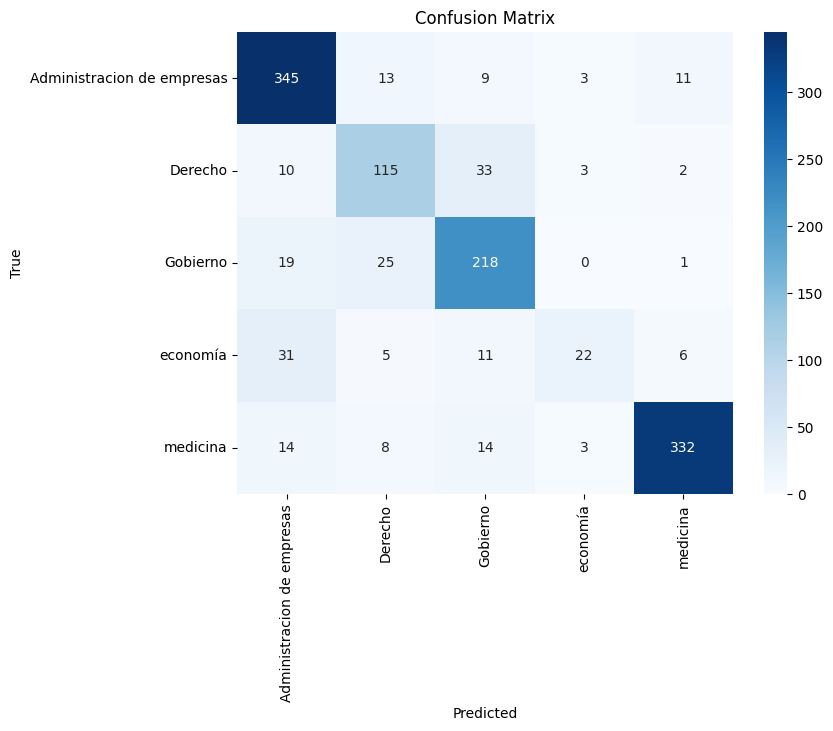


Distribución de predicciones:
Counter({np.str_('Administracion de empresas'): 419, np.str_('medicina'): 352, np.str_('Gobierno'): 285, np.str_('Derecho'): 166, np.str_('economía'): 31})

Accuracy por clase:

true
Administracion de empresas    0.905512
medicina                      0.894879
Gobierno                      0.828897
Derecho                       0.705521
economía                      0.293333
dtype: float64


In [27]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter


# --------------------------------------------------
# 1. Obtener predicciones del modelo
# --------------------------------------------------

predictions2 = trainer.predict(model, test_loader2)

predictions2 = torch.cat(predictions2, dim=0)

y_pred_ids = predictions2.numpy()

y_pred = [test_dataset2.id_2_class_map[p] for p in y_pred_ids]


# --------------------------------------------------
# 2. Obtener etiquetas reales
# --------------------------------------------------

# Correctly obtain true labels from the underlying dataset
y_true_categories = test_dataset2.dataset['facultad']
y_true_ids = [test_dataset2.class_2_id_map[cat] for cat in y_true_categories]
y_true = [test_dataset2.id_2_class_map[y] for y in y_true_ids]


# --------------------------------------------------
# 3. Accuracy
# --------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

print("\nAccuracy:", round(accuracy, 4))


# --------------------------------------------------
# 4. Precision, Recall, F1
# --------------------------------------------------

precision_macro = precision_score(y_true, y_pred, average="macro")
recall_macro = recall_score(y_true, y_pred, average="macro")
f1_macro = f1_score(y_true, y_pred, average="macro")

precision_weighted = precision_score(y_true, y_pred, average="weighted")
recall_weighted = recall_score(y_true, y_pred, average="weighted")
f1_weighted = f1_score(y_true, y_pred, average="weighted")

print("\n--- Métricas Macro ---")
print("Precision:", round(precision_macro, 4))
print("Recall:", round(recall_macro, 4))
print("F1-score:", round(f1_macro, 4))

print("\n--- Métricas Weighted ---")
print("Precision:", round(precision_weighted, 4))
print("Recall:", round(recall_weighted, 4))
print("F1-score:", round(f1_weighted, 4))


# --------------------------------------------------
# 5. Classification report
# --------------------------------------------------

print("\n--- Classification Report ---\n")

print(classification_report(y_true, y_pred))


# --------------------------------------------------
# 6. Confusion Matrix
# --------------------------------------------------

labels = sorted(list(set(y_true)))

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()


# --------------------------------------------------
# 7. Distribución de predicciones
# --------------------------------------------------

print("\nDistribución de predicciones:")

print(Counter(y_pred))


# --------------------------------------------------
# 8. Accuracy por clase
# --------------------------------------------------

df_eval = pd.DataFrame({
    "true": y_true,
    "pred": y_pred
})

accuracy_per_class = df_eval.groupby("true").apply(
    lambda x: (x.true == x.pred).mean()
)

print("\nAccuracy por clase:\n")

print(accuracy_per_class.sort_values(ascending=False))